# Fundamental Analysis
- 분석할 대상: IT(wics code: 45)

---

## 3단계: 기업 분석 
- 재무제표(대차대조표, 손익/포괄손익, 현금흐름표)를 통해 IT 산업에 속한 기업 분석 
- 어떤 회사들이 IT 산업 라이프사이클과 재무제표 정보를 통해 **부합**되도록 주식이 변동하였는지 
- 어떤 회사들이 IT 산업 라이프사이클과 재무제표 정보를 통해 **다르게** 주식이 변동하였는지 

- 참고할 파일들: 
    - `./data/analysis/it/*`   
    - `./data/재무제표/*`    

## 0. 라이브러리 임포트 및 경로 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
import warnings
warnings.filterwarnings('ignore')

try:
    import koreanize_matplotlib
except ImportError:
    plt.rcParams['font.family'] = 'Malgun Gothic'

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.unicode_minus'] = False

# 경로 설정
BASE_FS    = os.path.join('data', '재무제표')      # 재무제표 데이터
BASE_IT    = os.path.join('data', 'analysis', 'it')  # IT 분석 결과
OUT_DIR    = os.path.join('data', 'analysis', 'it')  # 저장 경로
os.makedirs(OUT_DIR, exist_ok=True)

IT_CODE = 'G45'   # WICS IT 섹터 코드 prefix
YEARS   = [2021, 2022, 2023, 2024]   # 분석 대상 연도 (재무제표 기준)

print('✅ 라이브러리 로딩 완료')

✅ 라이브러리 로딩 완료


---
## 1. IT 기업 목록 구성 (WICS + DART 매핑)

In [2]:
# WICS 최신 데이터에서 IT 기업 추출
wics_path = os.path.join(BASE_FS, 'wics_company_2026.csv')
df_wics = pd.read_csv(wics_path, encoding='utf-8-sig')
df_wics['CMP_CD'] = df_wics['CMP_CD'].astype(str).str.zfill(6)
df_wics['DATE']   = pd.to_datetime(df_wics['DATE'].astype(str), format='%Y%m%d')

# IT 섹터만 필터, 최신 날짜 기준
it_wics = df_wics[df_wics['IDX_CD'].str.startswith(IT_CODE)]
latest_date = it_wics['DATE'].max()
it_latest   = it_wics[it_wics['DATE'] == latest_date]

# 소분류별 상위 시총 기업 추출 (중복 제거 후 시총 기준 정렬)
it_companies = (
    it_latest[['IDX_CD', 'IDX_NM_KOR', 'CMP_CD', 'CMP_KOR', 'MKT_VAL']]
    .drop_duplicates('CMP_CD')
    .sort_values('MKT_VAL', ascending=False)
    .reset_index(drop=True)
)

# DART 코드 매핑
dart_path = os.path.join(BASE_FS, 'dart_company_2026.csv')
df_dart = pd.read_csv(dart_path, encoding='utf-8-sig')
df_dart['CMP_CD'] = df_dart['CMP_CD'].astype(str).str.zfill(6)
df_dart['DART_CD'] = df_dart['DART_CD'].astype('Int64')  # Int64 (nullable)

it_companies = it_companies.merge(df_dart[['CMP_CD', 'DART_CD']], on='CMP_CD', how='left')

print(f'IT 섹터 기업 수: {len(it_companies)}개 (기준일: {latest_date.date()})')
print(f'DART 코드 매핑 완료: {it_companies["DART_CD"].notna().sum()}개')
print()
print('상위 15개 기업 (시가총액 기준):')
display_cols = ['IDX_NM_KOR', 'CMP_CD', 'CMP_KOR', 'MKT_VAL', 'DART_CD']
print(it_companies[display_cols].head(15).to_string(index=False))

IT 섹터 기업 수: 705개 (기준일: 2026-03-27)
DART 코드 매핑 완료: 703개

상위 15개 기업 (시가총액 기준):
    IDX_NM_KOR CMP_CD  CMP_KOR   MKT_VAL  DART_CD
WICS 반도체와반도체장비 005930     삼성전자 797819201   126380
WICS 반도체와반도체장비 000660   SK하이닉스 486262570   164779
 WICS 전자와 전기제품 006400    삼성SDI  23854525   126362
WICS 기술하드웨어와장비 009150     삼성전기  23664457   126371
 WICS 전자와 전기제품 373220 LG에너지솔루션  13846950  1515323
 WICS 전자와 전기제품 066570     LG전자  12040562   401731
WICS 반도체와반도체장비 042700    한미반도체  11553745   161383
 WICS 전자와 전기제품 247540   에코프로비엠  10697758  1160363
WICS 기술하드웨어와장비 007660   이수페타시스   6002672   107613
WICS 소프트웨어와서비스 018260  삼성에스디에스   5926134   126186
WICS 반도체와반도체장비 058470     리노공업   5196505   369657
WICS 기술하드웨어와장비 011070    LG이노텍   4475332   105961
 WICS 전자와 전기제품 066970     엘앤에프   4258139   398701
WICS 반도체와반도체장비 240810    원익IPS   3860449  1135941
WICS 반도체와반도체장비 039030   이오테크닉스   3493332   246417


---
## 2. 재무제표 로딩 (손익계산서 기준)
- 연도별 손익계산서에서 IT 기업 데이터 추출
- 주요 계정: 매출액, 매출총이익, 영업이익, 당기순이익

In [3]:
# IT 기업 DART 코드 집합
it_dart_codes = set(it_companies['DART_CD'].dropna().astype(int).tolist())

# 주요 계정 ID → 한글 이름 매핑
ACCOUNT_MAP = {
    'ifrs-full_Revenue':             '매출액',
    'ifrs-full_GrossProfit':          '매출총이익',
    'dart_OperatingIncomeLoss':       '영업이익',
    'ifrs-full_ProfitLoss':           '당기순이익',
    'ifrs-full_ProfitLossBeforeTax':  '세전이익',
    'ifrs-full_CostOfSales':          '매출원가',
}

frames = []
for year in YEARS:
    fpath = os.path.join(BASE_FS, f'income_statement_{year}.csv')
    if not os.path.exists(fpath):
        print(f'⚠️ {fpath} 없음, 스킵')
        continue
    df = pd.read_csv(fpath, encoding='utf-8-sig', low_memory=False)
    # IT 기업 + 주요 계정 + 연결재무제표(CIS) 필터
    df = df[
        (df['corp_code'].isin(it_dart_codes)) &
        (df['account_id'].isin(ACCOUNT_MAP.keys())) &
        (df['sj_div'] == 'CIS')
    ].copy()
    df['year'] = year
    frames.append(df)

df_is = pd.concat(frames, ignore_index=True)
df_is['account_label'] = df_is['account_id'].map(ACCOUNT_MAP)
df_is['thstrm_amount'] = pd.to_numeric(df_is['thstrm_amount'], errors='coerce')
df_is['corp_code'] = df_is['corp_code'].astype(int)

# DART 코드 → 기업 정보 매핑
code2name = it_companies.dropna(subset=['DART_CD']).set_index('DART_CD')[['CMP_KOR','IDX_NM_KOR']].to_dict('index')
df_is['CMP_KOR']    = df_is['corp_code'].map(lambda x: code2name.get(x, {}).get('CMP_KOR', str(x)))
df_is['IDX_NM_KOR'] = df_is['corp_code'].map(lambda x: code2name.get(x, {}).get('IDX_NM_KOR', ''))

print(f'손익계산서 데이터: {len(df_is):,}행')
print(f'기업 수: {df_is["corp_code"].nunique()}개, 연도: {sorted(df_is["year"].unique())}')

손익계산서 데이터: 11,569행
기업 수: 584개, 연도: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


---
## 3. 기업별 매출액·영업이익 피벗 테이블 구성

In [4]:
# 피벗: 기업 × 연도 × 계정
df_pivot = df_is.pivot_table(
    index=['corp_code', 'CMP_KOR', 'IDX_NM_KOR'],
    columns=['year', 'account_label'],
    values='thstrm_amount',
    aggfunc='first'
)
df_pivot.columns = [f'{y}_{acct}' for y, acct in df_pivot.columns]
df_pivot = df_pivot.reset_index()

# 매출액 2024년 기준 정렬
rev_col = '2024_매출액' if '2024_매출액' in df_pivot.columns else f'{YEARS[-1]}_매출액'
df_pivot = df_pivot.sort_values(rev_col, ascending=False)

print(f'피벗 테이블 행 수: {len(df_pivot)}개 기업')
# 상위 10개 기업 매출액만 출력
show_cols = ['CMP_KOR', 'IDX_NM_KOR'] + [f'{y}_매출액' for y in YEARS if f'{y}_매출액' in df_pivot.columns]
top10 = df_pivot[show_cols].head(10).copy()
for c in show_cols[2:]:
    top10[c] = (top10[c] / 1e12).round(2)  # 조 원
top10.columns = ['기업명', 'WICS업종'] + [f'{c.split("_")[0]}년 매출(조원)' for c in show_cols[2:]]
print(top10.to_string(index=False))

피벗 테이블 행 수: 584개 기업
    기업명         WICS업종  2021년 매출(조원)  2022년 매출(조원)  2023년 매출(조원)  2024년 매출(조원)
 SK하이닉스 WICS 반도체와반도체장비         43.00         44.62         32.77         66.19
LG디스플레이     WICS 디스플레이         29.88         26.15         21.33         26.62
  삼성SDI  WICS 전자와 전기제품         13.55         20.12         22.71         16.59
   삼성전기 WICS 기술하드웨어와장비          9.68          9.42          8.91         10.29
아이티센글로벌 WICS 소프트웨어와서비스          3.28          2.62          2.82          4.96
 현대오토에버 WICS 소프트웨어와서비스          2.07          2.75          3.07          3.71
   삼지전자 WICS 기술하드웨어와장비          2.50          2.92          2.53          3.36
     영풍 WICS 기술하드웨어와장비          3.58          4.43          3.76          2.79
 에코프로비엠  WICS 전자와 전기제품          1.49          5.36          6.90          2.77
    NHN WICS 소프트웨어와서비스          1.92          2.11          2.27          2.46


---
## 4. 매출액 성장률 분석
- 연도별 매출액 추이 및 YoY 성장률
- IT 라이프사이클과의 정합성 확인

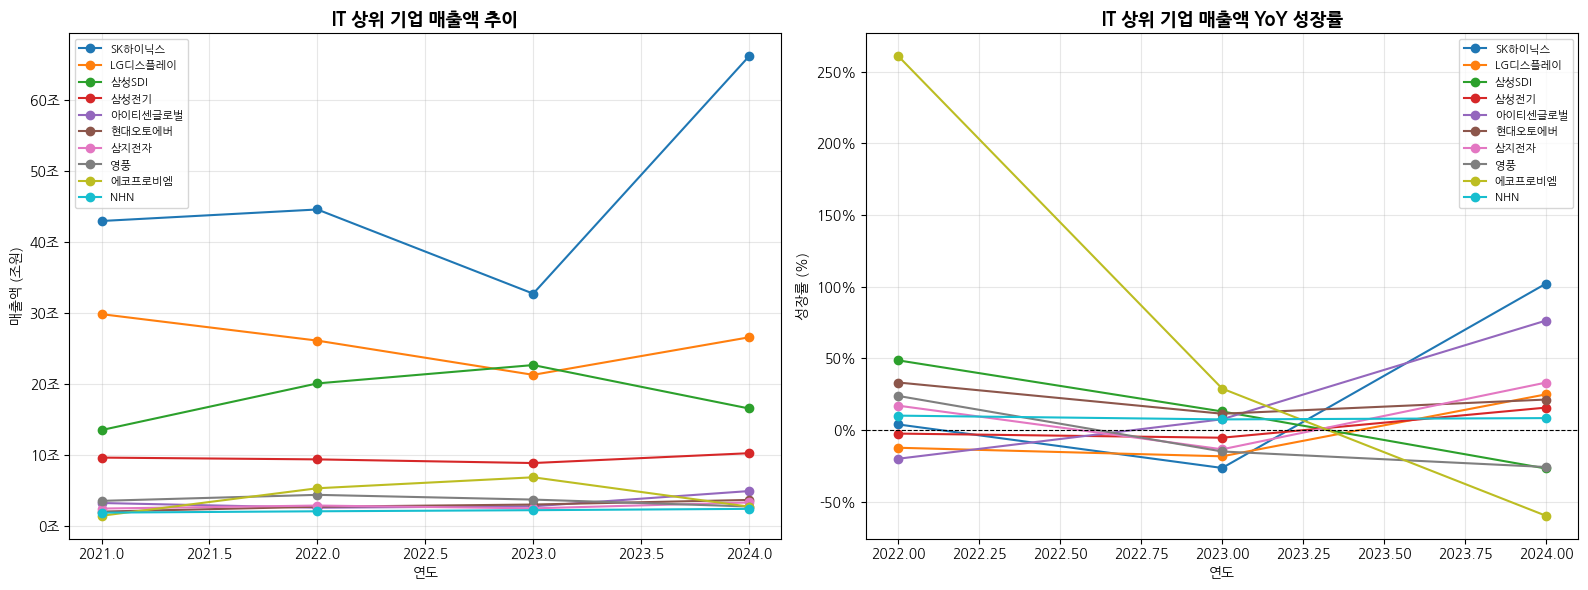


[매출액 성장률 요약]
  SK하이닉스      : CAGR +15.5%  (2021→2024)
  LG디스플레이     : CAGR -3.8%  (2021→2024)
  삼성SDI       : CAGR +7.0%  (2021→2024)
  삼성전기        : CAGR +2.1%  (2021→2024)
  아이티센글로벌     : CAGR +14.8%  (2021→2024)
  현대오토에버      : CAGR +21.5%  (2021→2024)
  삼지전자        : CAGR +10.4%  (2021→2024)
  영풍          : CAGR -8.0%  (2021→2024)
  에코프로비엠      : CAGR +23.0%  (2021→2024)
  NHN         : CAGR +8.5%  (2021→2024)


In [5]:
# 매출액 상위 10개 기업 추출
rev_cols = [f'{y}_매출액' for y in YEARS if f'{y}_매출액' in df_pivot.columns]
top10_rev = df_pivot.dropna(subset=rev_cols, how='all').head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (1) 매출액 절대값 추이
ax1 = axes[0]
for _, row in top10_rev.iterrows():
    vals = [row.get(f'{y}_매출액', np.nan) for y in YEARS]
    vals_t = [v / 1e12 for v in vals]  # 조 원
    ax1.plot(YEARS, vals_t, marker='o', label=row['CMP_KOR'])
ax1.set_title('IT 상위 기업 매출액 추이', fontsize=13, fontweight='bold')
ax1.set_ylabel('매출액 (조원)')
ax1.set_xlabel('연도')
ax1.legend(loc='upper left', fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}조'))

# (2) YoY 매출 성장률 (2022~2024)
ax2 = axes[1]
yoy_years = [y for y in YEARS if y > YEARS[0]]
for _, row in top10_rev.iterrows():
    growth = []
    for y in yoy_years:
        cur  = row.get(f'{y}_매출액', np.nan)
        prev = row.get(f'{y-1}_매출액', np.nan)
        g = (cur / prev - 1) * 100 if (pd.notna(cur) and pd.notna(prev) and prev != 0) else np.nan
        growth.append(g)
    ax2.plot(yoy_years, growth, marker='o', label=row['CMP_KOR'])
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('IT 상위 기업 매출액 YoY 성장률', fontsize=13, fontweight='bold')
ax2.set_ylabel('성장률 (%)')
ax2.set_xlabel('연도')
ax2.legend(loc='upper right', fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.show()

# 💡 인사이트 출력
print('\n[매출액 성장률 요약]')
for _, row in top10_rev.iterrows():
    r21 = row.get('2021_매출액', np.nan)
    r24 = row.get('2024_매출액', np.nan)
    if pd.notna(r21) and pd.notna(r24) and r21 != 0:
        cagr = ((r24 / r21) ** (1/3) - 1) * 100
        print(f'  {row["CMP_KOR"]:12s}: CAGR {cagr:+.1f}%  (2021→2024)')

---
## 5. 영업이익률 분석
- IT 기업의 수익성 변화 추적
- 라이프사이클(성장/성숙/침체) 구간과 수익성의 관계

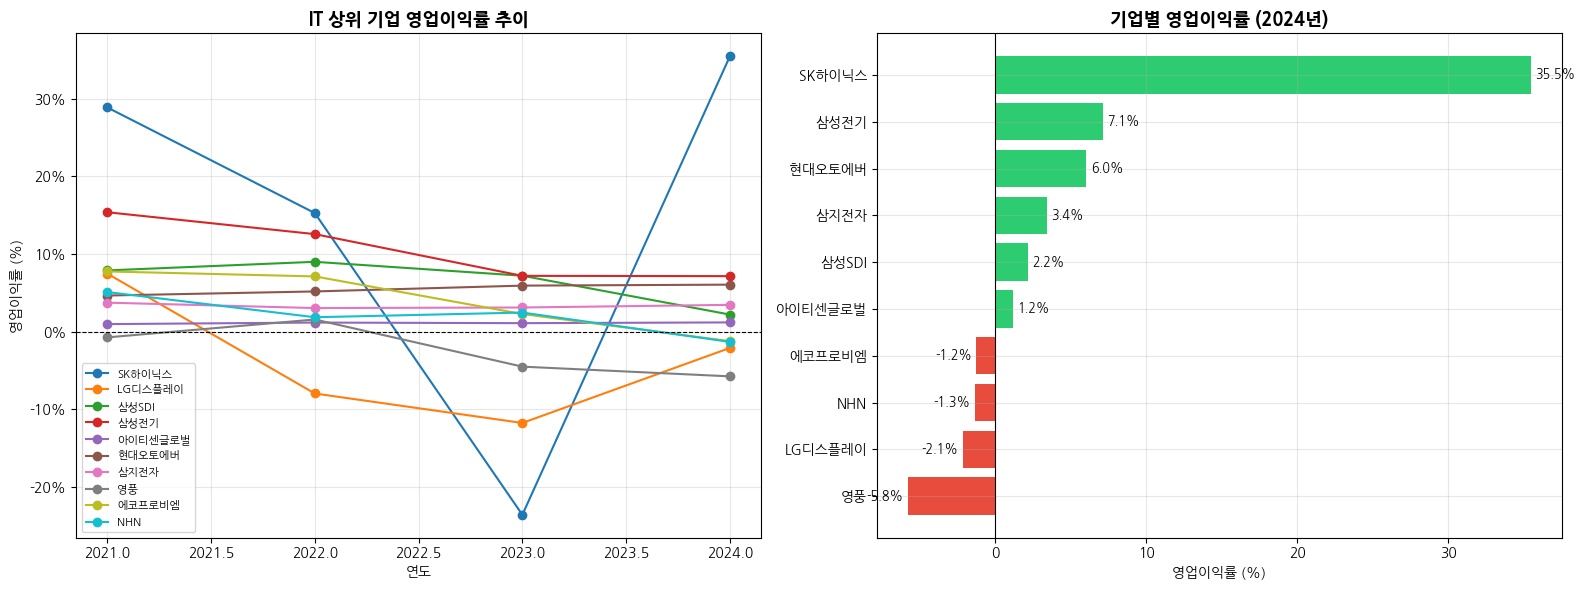


[2024년 영업이익률 현황]
     기업             업종     영업이익률
 SK하이닉스 WICS 반도체와반도체장비 35.452893
   삼성전기 WICS 기술하드웨어와장비  7.140067
 현대오토에버 WICS 소프트웨어와서비스  6.043545
   삼지전자 WICS 기술하드웨어와장비  3.441195
  삼성SDI  WICS 전자와 전기제품  2.189604
아이티센글로벌 WICS 소프트웨어와서비스  1.180301
 에코프로비엠  WICS 전자와 전기제품 -1.232792
    NHN WICS 소프트웨어와서비스 -1.328103
LG디스플레이     WICS 디스플레이 -2.106289
     영풍 WICS 기술하드웨어와장비 -5.765269


In [6]:
# 영업이익률 계산
op_rows = []
for _, row in top10_rev.iterrows():
    for y in YEARS:
        rev = row.get(f'{y}_매출액', np.nan)
        opi = row.get(f'{y}_영업이익', np.nan)
        margin = (opi / rev * 100) if (pd.notna(rev) and pd.notna(opi) and rev != 0) else np.nan
        op_rows.append({'기업': row['CMP_KOR'], '업종': row['IDX_NM_KOR'], '연도': y, '영업이익률': margin})

df_margin = pd.DataFrame(op_rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.tab10.colors

# (1) 영업이익률 추이
ax1 = axes[0]
for i, comp in enumerate(top10_rev['CMP_KOR']):
    sub = df_margin[df_margin['기업'] == comp]
    ax1.plot(sub['연도'], sub['영업이익률'], marker='o', label=comp, color=colors[i % 10])
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_title('IT 상위 기업 영업이익률 추이', fontsize=13, fontweight='bold')
ax1.set_ylabel('영업이익률 (%)')
ax1.set_xlabel('연도')
ax1.legend(fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# (2) 최신 연도 기업별 영업이익률 막대
ax2 = axes[1]
latest_yr = YEARS[-1]
latest_margin = df_margin[df_margin['연도'] == latest_yr].sort_values('영업이익률', ascending=True)
bar_colors = ['#E74C3C' if v < 0 else '#2ECC71' for v in latest_margin['영업이익률']]
ax2.barh(latest_margin['기업'], latest_margin['영업이익률'], color=bar_colors)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title(f'기업별 영업이익률 ({latest_yr}년)', fontsize=13, fontweight='bold')
ax2.set_xlabel('영업이익률 (%)')
for i, (_, r) in enumerate(latest_margin.iterrows()):
    v = r['영업이익률']
    if pd.notna(v):
        ax2.text(v + (0.3 if v >= 0 else -0.3), i, f'{v:.1f}%', va='center',
                 ha='left' if v >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

print(f'\n[{latest_yr}년 영업이익률 현황]')
print(latest_margin[['기업', '업종', '영업이익률']].sort_values('영업이익률', ascending=False).to_string(index=False))

---
## 6. 재무구조 분석 (대차대조표)
- 부채비율, 유동비율 기반의 재무 안정성 분석

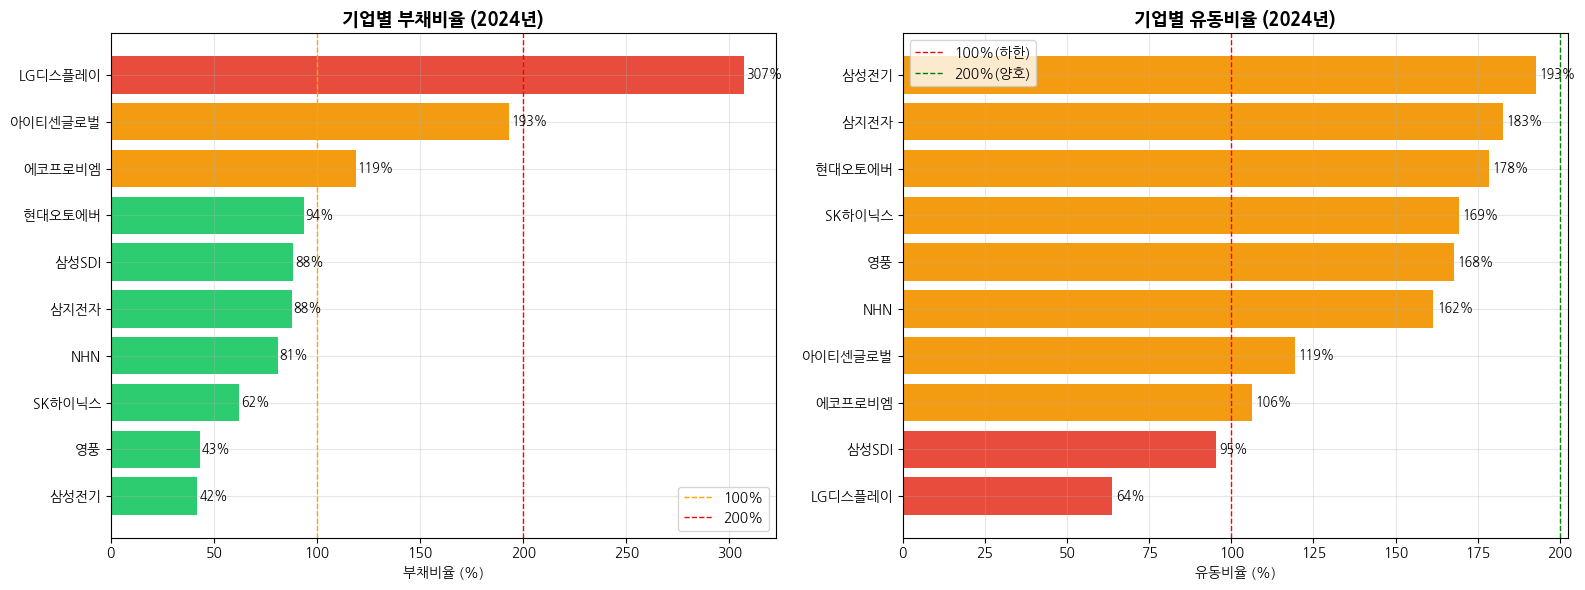


[2024년 재무 안정성 현황]
CMP_KOR       부채비율       유동비율
   삼성전기  41.887866 192.738458
     영풍  43.068423 167.692230
 SK하이닉스  62.151211 169.349630
    NHN  80.871370 161.515956
   삼지전자  87.726366 182.609728
  삼성SDI  88.236186  95.197164
 현대오토에버  93.554809 178.345029
 에코프로비엠 118.695845 106.227746
아이티센글로벌 193.169604 119.361523
LG디스플레이 307.040153  63.831158


In [7]:
BS_ACCOUNT_MAP = {
    'ifrs-full_Assets':              '자산총계',
    'ifrs-full_CurrentAssets':       '유동자산',
    'ifrs-full_NoncurrentAssets':    '비유동자산',
    'ifrs-full_Liabilities':         '부채총계',
    'ifrs-full_CurrentLiabilities':  '유동부채',
    'ifrs-full_Equity':              '자본총계',
}

bs_frames = []
for year in YEARS:
    fpath = os.path.join(BASE_FS, f'balance_sheet_{year}.csv')
    if not os.path.exists(fpath):
        continue
    df = pd.read_csv(fpath, encoding='utf-8-sig', low_memory=False)
    df = df[
        (df['corp_code'].isin(it_dart_codes)) &
        (df['account_id'].isin(BS_ACCOUNT_MAP.keys())) &
        (df['sj_div'] == 'BS')
    ].copy()
    df['year'] = year
    bs_frames.append(df)

df_bs = pd.concat(bs_frames, ignore_index=True)
df_bs['account_label'] = df_bs['account_id'].map(BS_ACCOUNT_MAP)
df_bs['thstrm_amount'] = pd.to_numeric(df_bs['thstrm_amount'], errors='coerce')
df_bs['corp_code'] = df_bs['corp_code'].astype(int)
df_bs['CMP_KOR'] = df_bs['corp_code'].map(lambda x: code2name.get(x, {}).get('CMP_KOR', str(x)))

# IT 상위 기업만
top10_codes = set(top10_rev['corp_code'].astype(int).tolist())
df_bs_top = df_bs[df_bs['corp_code'].isin(top10_codes)]

# 피벗
bs_pivot = df_bs_top.pivot_table(
    index=['corp_code', 'CMP_KOR'],
    columns=['year', 'account_label'],
    values='thstrm_amount',
    aggfunc='first'
)
bs_pivot.columns = [f'{y}_{acct}' for y, acct in bs_pivot.columns]
bs_pivot = bs_pivot.reset_index()

# 최신 연도 부채비율 = 부채총계 / 자본총계
ly = YEARS[-1]
if f'{ly}_부채총계' in bs_pivot.columns and f'{ly}_자본총계' in bs_pivot.columns:
    bs_pivot['부채비율'] = bs_pivot[f'{ly}_부채총계'] / bs_pivot[f'{ly}_자본총계'] * 100
else:
    bs_pivot['부채비율'] = np.nan

# 유동비율 = 유동자산 / 유동부채
if f'{ly}_유동자산' in bs_pivot.columns and f'{ly}_유동부채' in bs_pivot.columns:
    bs_pivot['유동비율'] = bs_pivot[f'{ly}_유동자산'] / bs_pivot[f'{ly}_유동부채'] * 100
else:
    bs_pivot['유동비율'] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (1) 부채비율
ax1 = axes[0]
sub = bs_pivot.dropna(subset=['부채비율']).sort_values('부채비율')
bar_c = ['#E74C3C' if v > 200 else '#F39C12' if v > 100 else '#2ECC71' for v in sub['부채비율']]
ax1.barh(sub['CMP_KOR'], sub['부채비율'], color=bar_c)
ax1.axvline(100, color='orange', linewidth=1, linestyle='--', label='100%')
ax1.axvline(200, color='red',    linewidth=1, linestyle='--', label='200%')
ax1.set_title(f'기업별 부채비율 ({ly}년)', fontsize=13, fontweight='bold')
ax1.set_xlabel('부채비율 (%)')
ax1.legend()
for i, (_, r) in enumerate(sub.iterrows()):
    if pd.notna(r['부채비율']):
        ax1.text(r['부채비율'] + 1, i, f'{r["부채비율"]:.0f}%', va='center', fontsize=9)

# (2) 유동비율
ax2 = axes[1]
sub2 = bs_pivot.dropna(subset=['유동비율']).sort_values('유동비율')
bar_c2 = ['#E74C3C' if v < 100 else '#2ECC71' if v > 200 else '#F39C12' for v in sub2['유동비율']]
ax2.barh(sub2['CMP_KOR'], sub2['유동비율'], color=bar_c2)
ax2.axvline(100, color='red',    linewidth=1, linestyle='--', label='100%(하한)')
ax2.axvline(200, color='green',  linewidth=1, linestyle='--', label='200%(양호)')
ax2.set_title(f'기업별 유동비율 ({ly}년)', fontsize=13, fontweight='bold')
ax2.set_xlabel('유동비율 (%)')
ax2.legend()
for i, (_, r) in enumerate(sub2.iterrows()):
    if pd.notna(r['유동비율']):
        ax2.text(r['유동비율'] + 1, i, f'{r["유동비율"]:.0f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'\n[{ly}년 재무 안정성 현황]')
fin_summary = bs_pivot[['CMP_KOR', '부채비율', '유동비율']].sort_values('부채비율')
print(fin_summary.to_string(index=False))

---
## 7. 현금흐름 분석
- 영업/투자/재무 활동 현금흐름으로 기업 성숙도 판단
- IT 라이프사이클 단계별 현금흐름 패턴:

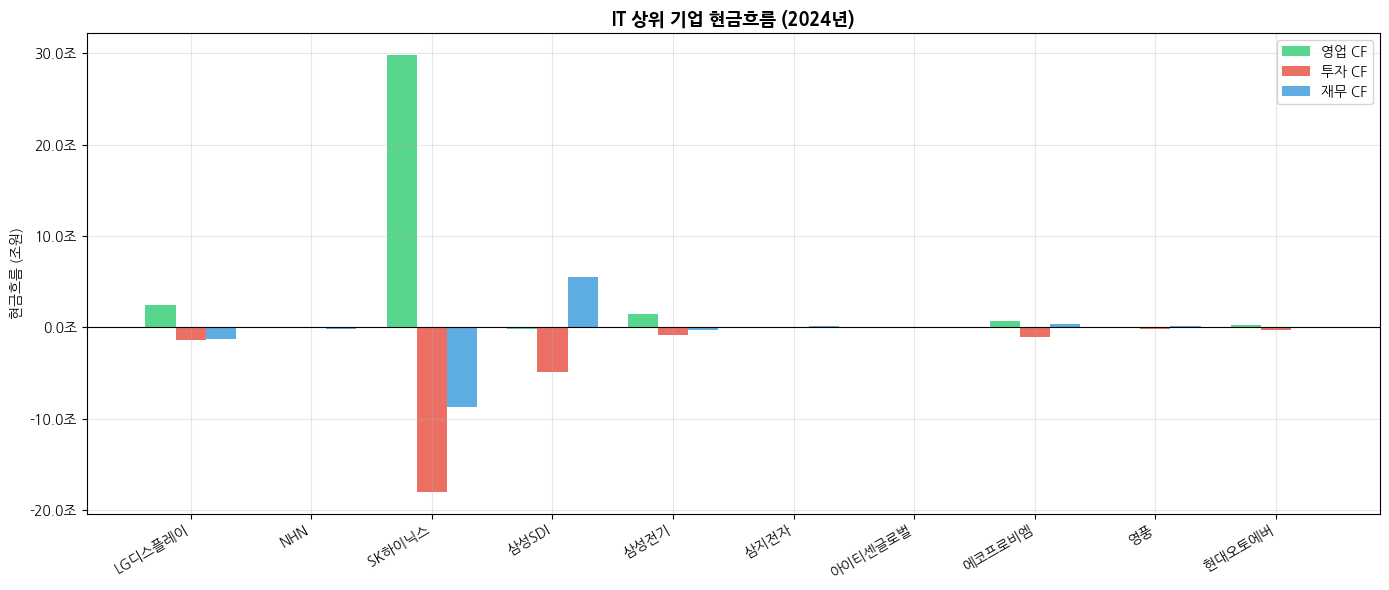


[2024년 현금흐름 현황 (조원)]
  LG디스플레이     : 영업 +2.41조, 투자 -1.36조, 재무 -1.33조  ✅ 성숙기 패턴
  NHN         : 영업 +0.05조, 투자 -0.05조, 재무 -0.15조  ✅ 성숙기 패턴
  SK하이닉스      : 영업 +29.80조, 투자 -18.00조, 재무 -8.70조  ✅ 성숙기 패턴
  삼성SDI       : 영업 -0.14조, 투자 -4.92조, 재무 +5.54조  🚀 초기/투자기
  삼성전기        : 영업 +1.43조, 투자 -0.81조, 재무 -0.31조  ✅ 성숙기 패턴
  삼지전자        : 영업 -0.11조, 투자 +0.00조, 재무 +0.13조  🚀 초기/투자기
  아이티센글로벌     : 영업 +0.03조, 투자 -0.06조, 재무 +0.07조  📈 성장기 패턴
  에코프로비엠      : 영업 +0.67조, 투자 -1.02조, 재무 +0.32조  📈 성장기 패턴
  영풍          : 영업 -0.00조, 투자 -0.22조, 재무 +0.16조  🚀 초기/투자기
  현대오토에버      : 영업 +0.26조, 투자 -0.27조, 재무 -0.09조  ✅ 성숙기 패턴


In [8]:
CF_ACCOUNT_MAP = {
    'ifrs-full_CashFlowsFromUsedInOperatingActivities':   '영업CF',
    'ifrs-full_CashFlowsFromUsedInInvestingActivities':   '투자CF',
    'ifrs-full_CashFlowsFromUsedInFinancingActivities':   '재무CF',
    # 일부 회사는 아래 ID를 사용
    'dart_CashFlowsFromOperatingActivities':              '영업CF',
    'dart_CashFlowsUsedInInvestingActivities':            '투자CF',
    'dart_CashFlowsUsedInFinancingActivities':            '재무CF',
}

cf_frames = []
for year in YEARS:
    fpath = os.path.join(BASE_FS, f'cash_flow_{year}.csv')
    if not os.path.exists(fpath):
        continue
    df = pd.read_csv(fpath, encoding='utf-8-sig', low_memory=False)
    df = df[
        (df['corp_code'].isin(top10_codes)) &
        (df['account_id'].isin(CF_ACCOUNT_MAP.keys()))
    ].copy()
    df['year'] = year
    cf_frames.append(df)

df_cf = pd.concat(cf_frames, ignore_index=True)
df_cf['account_label'] = df_cf['account_id'].map(CF_ACCOUNT_MAP)
df_cf['thstrm_amount'] = pd.to_numeric(df_cf['thstrm_amount'], errors='coerce')
df_cf['corp_code'] = df_cf['corp_code'].astype(int)
df_cf['CMP_KOR'] = df_cf['corp_code'].map(lambda x: code2name.get(x, {}).get('CMP_KOR', str(x)))

# 중복 집계 제거 (같은 기업/연도/계정에서 가장 큰 값 선택 by 절댓값)
df_cf = df_cf.groupby(['corp_code', 'CMP_KOR', 'year', 'account_label'], as_index=False)['thstrm_amount'].first()

# 최신 연도 현금흐름 시각화
ly = YEARS[-1]
cf_latest = df_cf[df_cf['year'] == ly].pivot_table(
    index='CMP_KOR', columns='account_label', values='thstrm_amount', aggfunc='first'
).reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
comps = cf_latest['CMP_KOR'].tolist()
x = np.arange(len(comps))
w = 0.25

for i, (col, label, color) in enumerate([
    ('영업CF', '영업 CF', '#2ECC71'),
    ('투자CF', '투자 CF', '#E74C3C'),
    ('재무CF', '재무 CF', '#3498DB')
]):
    if col in cf_latest.columns:
        vals = cf_latest[col].fillna(0) / 1e12
        ax.bar(x + i * w, vals, w, label=label, color=color, alpha=0.8)

ax.set_xticks(x + w)
ax.set_xticklabels(comps, rotation=30, ha='right')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title(f'IT 상위 기업 현금흐름 ({ly}년)', fontsize=13, fontweight='bold')
ax.set_ylabel('현금흐름 (조원)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}조'))
ax.legend()
plt.tight_layout()
plt.show()

print(f'\n[{ly}년 현금흐름 현황 (조원)]')
for _, row in cf_latest.iterrows():
    op  = row.get('영업CF', np.nan)
    inv = row.get('투자CF', np.nan)
    fin = row.get('재무CF', np.nan)
    pattern = ''
    if pd.notna(op) and pd.notna(inv):
        if op > 0 and inv < 0:
            pattern = '📈 성장기 패턴' if fin > 0 else '✅ 성숙기 패턴'
        elif op < 0:
            pattern = '🚀 초기/투자기'
    print(f'  {row["CMP_KOR"]:12s}: 영업 {op/1e12:+.2f}조, 투자 {inv/1e12:+.2f}조, 재무 {fin/1e12:+.2f}조  {pattern}')

---
## 8. IT 라이프사이클 vs 주가 변동 분석
- IT 섹터 시총 추이(라이프사이클)와 기업별 시가총액 변동 비교
- **정합 기업**: 섹터 추이와 함께 오른/내린 기업
- **이탈 기업**: 섹터 추이와 반대 방향으로 움직인 기업

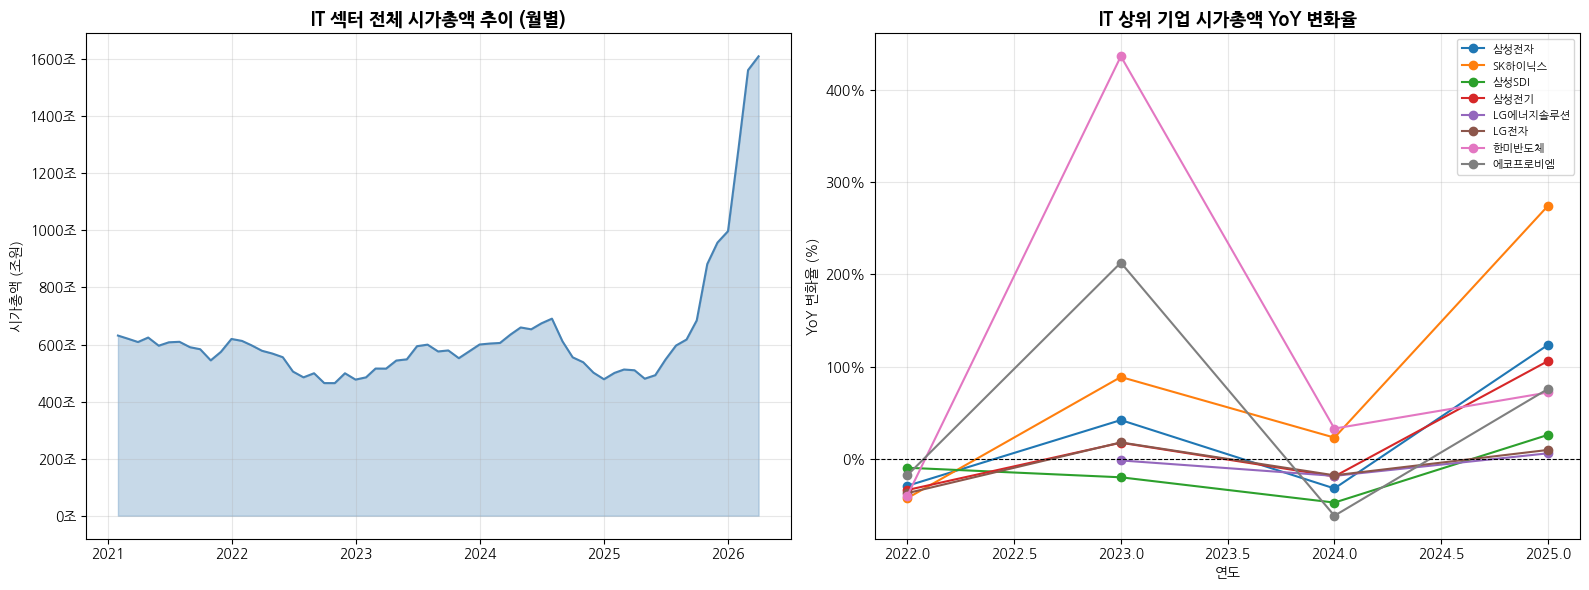

In [9]:
# IT 섹터 전체 월별 시총 로드
it_mc_path = os.path.join(BASE_IT, 'it_market_cap_monthly.csv')
df_mc = pd.read_csv(it_mc_path, encoding='utf-8-sig', index_col=0, parse_dates=True)

# WICS 연도별 기업별 시총 (최신 기준)
# 각 연도 말 시총 비교
annual_mkt = []
for year in YEARS + [2025]:
    fpath = os.path.join('data', 'wics', f'wics_company_{year}.zip') if year < 2026 else \
            os.path.join(BASE_FS, 'wics_company_2026.csv')
    if not os.path.exists(fpath):
        continue
    df = pd.read_csv(fpath, encoding='utf-8-sig', low_memory=False)
    df['CMP_CD'] = df['CMP_CD'].astype(str).str.zfill(6)
    df['DATE']   = pd.to_datetime(df['DATE'].astype(str), format='%Y%m%d')
    df_it = df[df['IDX_CD'].str.startswith(IT_CODE)]
    # 年말 또는 최신 날짜 기준
    latest = df_it['DATE'].max()
    df_it_latest = df_it[df_it['DATE'] == latest][['CMP_CD', 'CMP_KOR', 'MKT_VAL']].drop_duplicates('CMP_CD')
    df_it_latest['year'] = year
    annual_mkt.append(df_it_latest)

if annual_mkt:
    df_annual = pd.concat(annual_mkt, ignore_index=True)
    # 상위 8개 기업 필터
    top8_codes = it_companies.head(8)['CMP_CD'].tolist()
    df_top8 = df_annual[df_annual['CMP_CD'].isin(top8_codes)]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # (1) IT 섹터 전체 시총 추이
    ax1 = axes[0]
    ax1.fill_between(df_mc.index, df_mc.iloc[:, 0] / 1e6, alpha=0.3, color='steelblue')
    ax1.plot(df_mc.index, df_mc.iloc[:, 0] / 1e6, color='steelblue', linewidth=1.5)
    ax1.set_title('IT 섹터 전체 시가총액 추이 (월별)', fontsize=13, fontweight='bold')
    ax1.set_ylabel('시가총액 (조원)')
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}조'))

    # (2) 기업별 시총 YoY 변화율
    ax2 = axes[1]
    years_avail = sorted(df_top8['year'].unique())
    for cmp_cd in top8_codes:
        sub = df_top8[df_top8['CMP_CD'] == cmp_cd].sort_values('year')
        if len(sub) < 2:
            continue
        name = sub['CMP_KOR'].iloc[0]
        yearly_chg = []
        yrs = []
        for i in range(1, len(sub)):
            prev = sub['MKT_VAL'].iloc[i-1]
            curr = sub['MKT_VAL'].iloc[i]
            if prev > 0:
                yearly_chg.append((curr / prev - 1) * 100)
                yrs.append(sub['year'].iloc[i])
        ax2.plot(yrs, yearly_chg, marker='o', label=name)

    ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax2.set_title('IT 상위 기업 시가총액 YoY 변화율', fontsize=13, fontweight='bold')
    ax2.set_ylabel('YoY 변화율 (%)')
    ax2.set_xlabel('연도')
    ax2.legend(fontsize=8)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

    plt.tight_layout()
    plt.show()
else:
    print('⚠️ WICS 연도별 데이터 없음 - 분석 생략')

---
## 9. 재무 성과 vs 주가 변동 상관 분석
- 영업이익률 vs 시가총액 변화율 산점도
- 재무제표와 주가 변동의 정합성 시각화

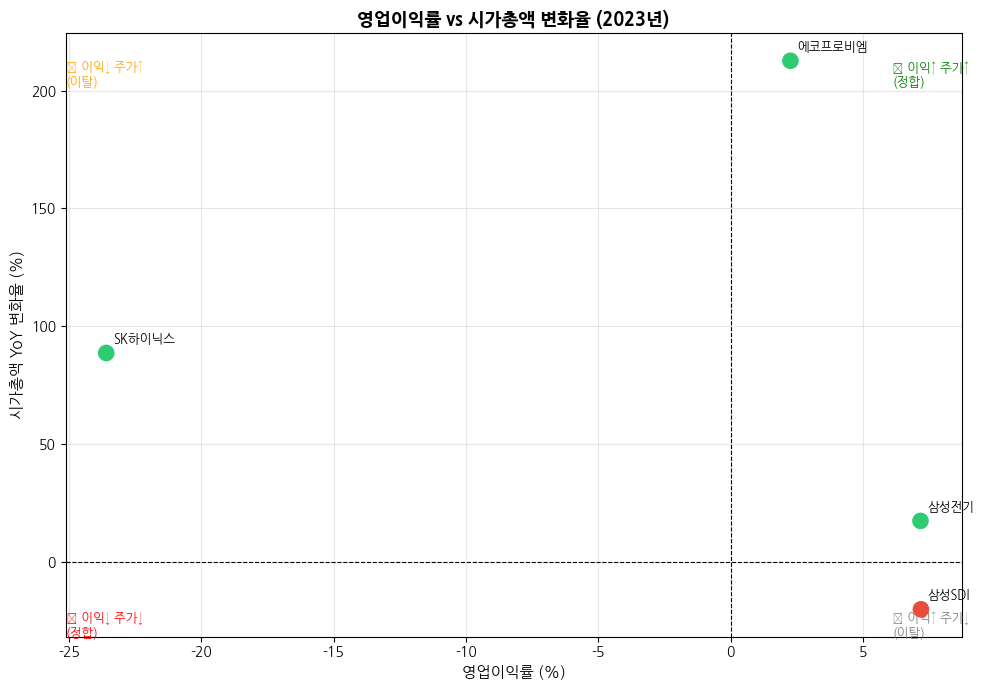


[2023년 정합성 분류]
    기업      영업이익률      시총변화율           분류
SK하이닉스 -23.592685  88.666669         ⚡ 이탈
 삼성SDI   7.192828 -20.135365         ⚡ 이탈
  삼성전기   7.176917  17.394633 ✅ 정합(이익↑주가↑)
에코프로비엠   2.261019 212.703553 ✅ 정합(이익↑주가↑)


In [10]:
# 분석 연도 설정 (재무제표 + 주가 모두 존재하는 연도)
analysis_year = 2023
prev_year     = analysis_year - 1

# 영업이익률 (손익계산서)
df_margin_yr = df_margin[df_margin['연도'] == analysis_year][['기업', '영업이익률']]

# 기업별 시총 변화율 (WICS)
mkt_change = []
for cmp_cd in top8_codes:
    sub = df_top8[df_top8['CMP_CD'] == cmp_cd].sort_values('year')
    r_curr = sub[sub['year'] == analysis_year]['MKT_VAL'].values
    r_prev = sub[sub['year'] == prev_year]['MKT_VAL'].values
    if len(r_curr) > 0 and len(r_prev) > 0 and r_prev[0] > 0:
        chg = (r_curr[0] / r_prev[0] - 1) * 100
        name = sub['CMP_KOR'].iloc[0]
        mkt_change.append({'기업': name, '시총변화율': chg})

df_scatter = pd.DataFrame(mkt_change).merge(df_margin_yr, on='기업', how='inner')

if not df_scatter.empty:
    fig, ax = plt.subplots(figsize=(10, 7))
    colors_s = ['#2ECC71' if v > 0 else '#E74C3C' for v in df_scatter['시총변화율']]
    ax.scatter(df_scatter['영업이익률'], df_scatter['시총변화율'],
               s=120, c=colors_s, zorder=5)
    for _, r in df_scatter.iterrows():
        ax.annotate(r['기업'], (r['영업이익률'], r['시총변화율']),
                    fontsize=9, ha='left', va='bottom', xytext=(5, 5), textcoords='offset points')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('영업이익률 (%)', fontsize=11)
    ax.set_ylabel('시가총액 YoY 변화율 (%)', fontsize=11)
    ax.set_title(f'영업이익률 vs 시가총액 변화율 ({analysis_year}년)', fontsize=13, fontweight='bold')
    # 사분면 레이블
    ax.text(ax.get_xlim()[1]*0.7, ax.get_ylim()[1]*0.9, '✅ 이익↑ 주가↑\n(정합)', color='green', fontsize=9)
    ax.text(ax.get_xlim()[0],     ax.get_ylim()[1]*0.9, '⚡ 이익↓ 주가↑\n(이탈)', color='orange', fontsize=9)
    ax.text(ax.get_xlim()[0],     ax.get_ylim()[0],     '🔴 이익↓ 주가↓\n(정합)', color='red',    fontsize=9)
    ax.text(ax.get_xlim()[1]*0.7, ax.get_ylim()[0],     '❓ 이익↑ 주가↓\n(이탈)', color='gray',   fontsize=9)
    plt.tight_layout()
    plt.show()

    print(f'\n[{analysis_year}년 정합성 분류]')
    df_scatter['분류'] = df_scatter.apply(
        lambda r: '✅ 정합(이익↑주가↑)' if r['영업이익률'] > 0 and r['시총변화율'] > 0
        else ('🔴 정합(이익↓주가↓)' if r['영업이익률'] < 0 and r['시총변화율'] < 0
        else '⚡ 이탈'), axis=1
    )
    print(df_scatter[['기업', '영업이익률', '시총변화율', '분류']].to_string(index=False))
else:
    print('⚠️ 산점도 데이터 부족 - 분석 생략')

---
## 10. 종합 요약 리포트
- IT 섹터 기업 분석 결과 종합
- 라이프사이클 정합/이탈 기업 최종 정리

In [11]:
print('=' * 60)
print('  IT 섹터 기업 분석 종합 리포트')
print('=' * 60)

# ----- (A) 수익성 순위 -----
latest_yr = YEARS[-1]
ranking_margin = df_margin[df_margin['연도'] == latest_yr].sort_values('영업이익률', ascending=False)

print(f'\n📊 [수익성 순위 - {latest_yr}년 영업이익률]')
for rank, (_, r) in enumerate(ranking_margin.iterrows(), 1):
    m = r['영업이익률']
    if pd.notna(m):
        icon = '🟢' if m > 10 else '🟡' if m > 0 else '🔴'
        print(f'  {rank:2d}위 {icon} {r["기업"]:12s}: {m:+.1f}%')

# ----- (B) 재무 안정성 -----
print(f'\n🏦 [재무 안정성 - {latest_yr}년 부채비율]')
fin_sorted = fin_summary.sort_values('부채비율')
for _, r in fin_sorted.iterrows():
    d = r['부채비율']
    l = r['유동비율']
    if pd.notna(d):
        d_icon = '✅' if d < 100 else '⚠️' if d < 200 else '🚨'
        l_txt  = f'유동비율 {l:.0f}%' if pd.notna(l) else ''
        print(f'  {d_icon} {r["CMP_KOR"]:12s}: 부채비율 {d:.0f}%  {l_txt}')

# ----- (C) 성장성 요약 -----
print('\n📈 [성장성 요약 - 매출액 CAGR 2021→2024]')
for _, row in top10_rev.iterrows():
    r21 = row.get('2021_매출액', np.nan)
    r24 = row.get('2024_매출액', np.nan)
    if pd.notna(r21) and pd.notna(r24) and r21 > 0:
        cagr = ((r24 / r21) ** (1/3) - 1) * 100
        icon = '🚀' if cagr > 15 else '📈' if cagr > 0 else '📉'
        print(f'  {icon} {row["CMP_KOR"]:12s}: CAGR {cagr:+.1f}%')

print('\n' + '=' * 60)
print('✅ 분석 완료')

  IT 섹터 기업 분석 종합 리포트

📊 [수익성 순위 - 2024년 영업이익률]
   1위 🟢 SK하이닉스      : +35.5%
   2위 🟡 삼성전기        : +7.1%
   3위 🟡 현대오토에버      : +6.0%
   4위 🟡 삼지전자        : +3.4%
   5위 🟡 삼성SDI       : +2.2%
   6위 🟡 아이티센글로벌     : +1.2%
   7위 🔴 에코프로비엠      : -1.2%
   8위 🔴 NHN         : -1.3%
   9위 🔴 LG디스플레이     : -2.1%
  10위 🔴 영풍          : -5.8%

🏦 [재무 안정성 - 2024년 부채비율]
  ✅ 삼성전기        : 부채비율 42%  유동비율 193%
  ✅ 영풍          : 부채비율 43%  유동비율 168%
  ✅ SK하이닉스      : 부채비율 62%  유동비율 169%
  ✅ NHN         : 부채비율 81%  유동비율 162%
  ✅ 삼지전자        : 부채비율 88%  유동비율 183%
  ✅ 삼성SDI       : 부채비율 88%  유동비율 95%
  ✅ 현대오토에버      : 부채비율 94%  유동비율 178%
  ⚠️ 에코프로비엠      : 부채비율 119%  유동비율 106%
  ⚠️ 아이티센글로벌     : 부채비율 193%  유동비율 119%
  🚨 LG디스플레이     : 부채비율 307%  유동비율 64%

📈 [성장성 요약 - 매출액 CAGR 2021→2024]
  🚀 SK하이닉스      : CAGR +15.5%
  📉 LG디스플레이     : CAGR -3.8%
  📈 삼성SDI       : CAGR +7.0%
  📈 삼성전기        : CAGR +2.1%
  📈 아이티센글로벌     : CAGR +14.8%
  🚀 현대오토에버      : CAGR +21.5%
  📈 삼지전자        : CAGR +10.4%
  📉 영풍          : CAGR -

---
## 11. 결과 저장

In [12]:
# (1) 기업별 영업이익률 저장
margin_save = df_margin.pivot_table(index='기업', columns='연도', values='영업이익률').round(2)
margin_save.to_csv(os.path.join(OUT_DIR, 'it_company_op_margin.csv'), encoding='utf-8-sig')
print('✅ 저장: it_company_op_margin.csv')

# (2) 재무 안정성 지표 저장
if 'fin_summary' in dir():
    fin_summary.to_csv(os.path.join(OUT_DIR, 'it_company_fin_stability.csv'),
                       encoding='utf-8-sig', index=False)
    print('✅ 저장: it_company_fin_stability.csv')

# (3) 현금흐름 저장
df_cf.to_csv(os.path.join(OUT_DIR, 'it_company_cashflow.csv'),
             encoding='utf-8-sig', index=False)
print('✅ 저장: it_company_cashflow.csv')

# (4) 라이프사이클 정합성 분류 저장 (산점도 데이터)
if 'df_scatter' in dir() and not df_scatter.empty:
    df_scatter.to_csv(os.path.join(OUT_DIR, 'it_company_lifecycle_match.csv'),
                      encoding='utf-8-sig', index=False)
    print('✅ 저장: it_company_lifecycle_match.csv')

print('\n📁 저장 위치:', OUT_DIR)

✅ 저장: it_company_op_margin.csv
✅ 저장: it_company_fin_stability.csv
✅ 저장: it_company_cashflow.csv
✅ 저장: it_company_lifecycle_match.csv

📁 저장 위치: data\analysis\it
